<a href="https://colab.research.google.com/github/engineerchacon/Maestria-en-Inteligencia-Artificial-y-Analitica-de-Datos-Colab-Files/blob/main/Semana_13_imbalanceddataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unidad 04: Preprocesamiento de los Datos - Clases No Balanceadas


# Contenido detallado de clase para Google Colab sobre clases no balanceadas
# 🎓 Clase Completa: Clasificación con Clases No Balanceadas en Machine Learning

## 👨‍🏫 Nivel: Maestría  
**Duración estimada:** 1.5 a 2 horas  
**Modalidad:** Teórico-práctica (Google Colab)

---

## 🧠 Objetivos de Aprendizaje

- Comprender los desafíos que representan las clases no balanceadas en modelos predictivos.
- Evaluar modelos usando métricas adecuadas para conjuntos desbalanceados.
- Aplicar técnicas como `class_weight` y `SMOTE` para mitigar el desbalance.
- Comparar el rendimiento de modelos con y sin tratamiento del desbalance.

---


## 1️⃣ Generación y Visualización de un Dataset Desbalanceado

target
0    897
1    103
Name: count, dtype: int64


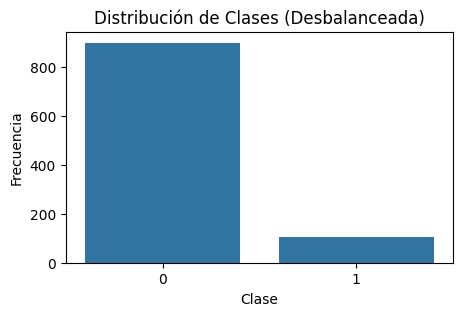

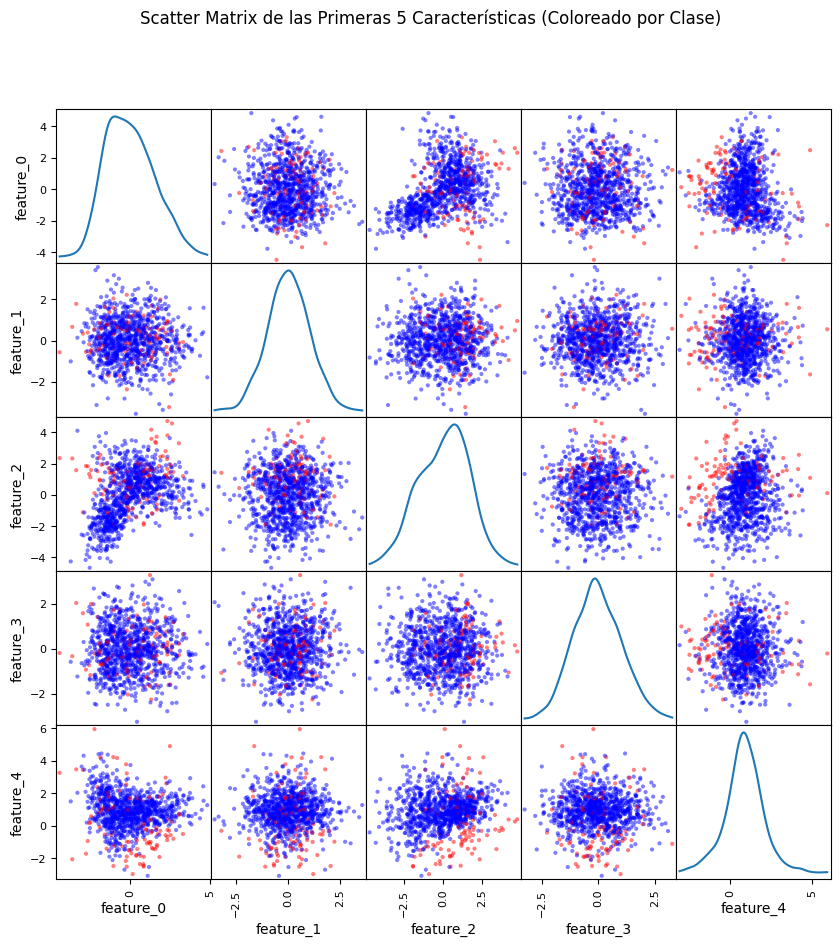

In [ ]:
# ---------------------------------------------
# Paso 1: Generar un dataset desbalanceado
# ---------------------------------------------

from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from pandas.plotting import scatter_matrix

X, y = make_classification(n_samples=1000, n_features=10, n_informative=5,
                           n_redundant=0, weights=[0.9, 0.1], random_state=42)

# Crear un DataFrame para exploración inicial
df = pd.DataFrame(X, columns=[f"feature_{i}" for i in range(X.shape[1])])
df['target'] = y
print(df['target'].value_counts())

plt.figure(figsize=(5, 3))
sns.countplot(x='target', data=df)
plt.title("Distribución de Clases (Desbalanceada)")
plt.xlabel("Clase")
plt.ylabel("Frecuencia")
plt.show()

# Visualización adicional: scatter matrix coloreada por clase
colors = df['target'].map({0: 'blue', 1: 'red'})
scatter_matrix(df[df.columns[:5]], figsize=(10, 10), diagonal='kde', alpha=0.5, color=colors)
plt.suptitle("Scatter Matrix de las Primeras 5 Características (Coloreado por Clase)")
plt.show()


##Paso 2: Entrenar modelo sin tratar el desbalance

En este ejemplo hemos considerado usar un hold-out 70-30 y un K-NN como clasificador.


Modelo sin tratamiento de desbalance:
              precision    recall  f1-score   support

           0      0.996     1.000     0.998       269
           1      1.000     0.968     0.984        31

    accuracy                          0.997       300
   macro avg      0.998     0.984     0.991       300
weighted avg      0.997     0.997     0.997       300


📊 Distribución de clases Entrenamiento:
Clase 0 (mayoritaria): 626 (89.43%)
Clase 1 (minoritaria): 74 (10.57%)
Ratio de desbalance: 1:8.5

📊 Distribución de clases Test:
Clase 0 (mayoritaria): 269 (89.67%)
Clase 1 (minoritaria): 31 (10.33%)
Ratio de desbalance: 1:8.7


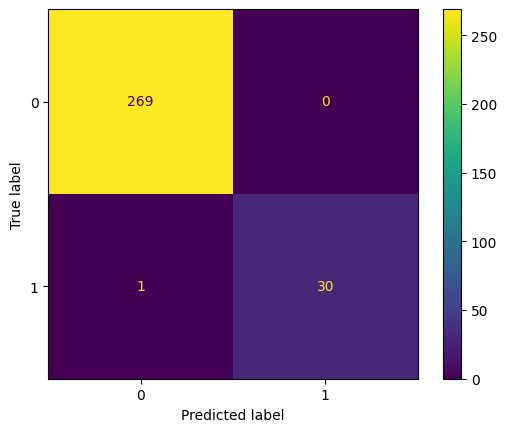

In [ ]:

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from collections import Counter


X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

modelo_baseline = KNeighborsClassifier(n_neighbors=3)
modelo_baseline.fit(X_train, y_train)
y_pred = modelo_baseline.predict(X_test)

print("Modelo sin tratamiento de desbalance:")
print(classification_report(y_test, y_pred, digits=3))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

# Análisis del desbalance
print(f"\n📊 Distribución de clases Entrenamiento:")
train_dist = Counter(y_train)
print(f"Clase 0 (mayoritaria): {train_dist[0]} ({train_dist[0]/len(y_train)*100:.2f}%)")
print(f"Clase 1 (minoritaria): {train_dist[1]} ({train_dist[1]/len(y_train)*100:.2f}%)")
print(f"Ratio de desbalance: 1:{train_dist[0]/train_dist[1]:.1f}")

# Análisis del desbalance
print(f"\n📊 Distribución de clases Test:")
tst_dist = Counter(y_test)
print(f"Clase 0 (mayoritaria): {tst_dist[0]} ({tst_dist[0]/len(y_test)*100:.2f}%)")
print(f"Clase 1 (minoritaria): {tst_dist[1]} ({tst_dist[1]/len(y_test)*100:.2f}%)")
print(f"Ratio de desbalance: 1:{tst_dist[0]/tst_dist[1]:.1f}")



## Efecto del Desbalance en K-NN

Dependiendo de la configuración del clasificador el efecto del desbalance puede ser más agresivo. En este ejemplo usamos el mismo conjunto de datos con diferentes valores de K.

Observa que para distintos valores de K el TPR desciende. En el caso del TNR se mantiene con valores > 0.9

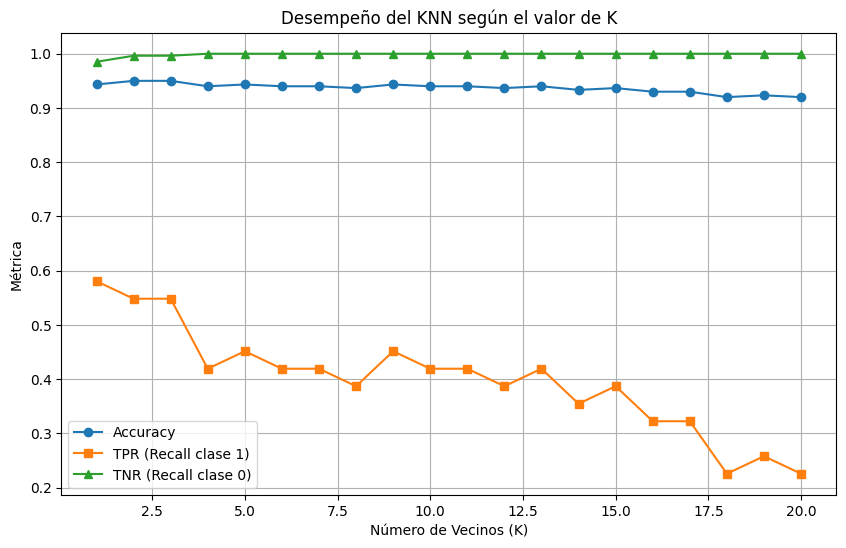

In [ ]:
# ---------------------------------------------
# Visualización de rendimiento con KNN para diferentes valores de K
# ---------------------------------------------

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

k_values = list(range(1, 21))
accuracy = []
tpr_list = []
tnr_list = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred_knn = knn.predict(X_test)
    cm = confusion_matrix(y_test, y_pred_knn)
    tn, fp, fn, tp = cm.ravel()
    acc = accuracy_score(y_test, y_pred_knn)
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    tnr = tn / (tn + fp) if (tn + fp) > 0 else 0
    accuracy.append(acc)
    tpr_list.append(tpr)
    tnr_list.append(tnr)

# Graficar métricas
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracy, label='Accuracy', marker='o')
plt.plot(k_values, tpr_list, label='TPR (Recall clase 1)', marker='s')
plt.plot(k_values, tnr_list, label='TNR (Recall clase 0)', marker='^')
plt.xlabel('Número de Vecinos (K)')
plt.ylabel('Métrica')
plt.title('Desempeño del KNN según el valor de K')
plt.legend()
plt.grid(True)
plt.show()

## Instalación de Imbalanced-Learn
En esta clase emplearemos esta biblioteca. Para ello, deberemos instalar dicho paquete.


```python
# imbalanced-learn instalación
!pip install -q imbalanced-learn
```



In [ ]:
!pip install -q imbalanced-learn

# ============================================================================
# SECCIÓN 8: TÉCNICA 4 - SMOTE + K-NN
# ============================================================================

💡 CONCEPTO: SMOTE y K-NN tienen una relación especial

SMOTE (Synthetic Minority Over-sampling Technique) usa K-NN para:
1. Encontrar vecinos minoritarios cercanos
2. Interpolar entre ellos para crear ejemplos sintéticos

¡Es K-NN creando datos para K-NN!

VENTAJAS:
✓ Aumenta ejemplos minoritarios sin duplicar
✓ Los vecinos minoritarios tienen más representación
✓ Mejora las fronteras de decisión

VARIANTES DE SMOTE:
• SMOTE regular: K-NN simple
• Borderline SMOTE: Solo en la frontera
• SVM SMOTE: Usa SVM para encontrar frontera
• ADASYN: Más ejemplos donde hay más dificultad


🔬 Aplicando SMOTE...
Dataset original: Counter({np.int64(0): 626, np.int64(1): 74})
Dataset con SMOTE: Counter({np.int64(0): 626, np.int64(1): 626})
Modelo con tratamiento de desbalance:
              precision    recall  f1-score   support

           0      0.996     0.955     0.975       269
           1      0.714     0.968     0.822        31

    accuracy                          0.957       300
   macro avg      0.855     0.962     0.899       300
weighted avg      0.967     0.957     0.959       300


📊 Distribución de clases Entrenamiento Original:
Clase 0 (mayoritaria): 626 (89.43%)
Clase 1 (minoritaria): 74 (10.57%)
Ratio de desbalance: 1:8.5

📊 Distribución de clases Entrenamiento Balanceada:
Clase 0 (mayoritaria): 626 (50.00%)
Clase 1 (minoritaria): 626 (50.00%)
Ratio de desbalance: 1:1.0


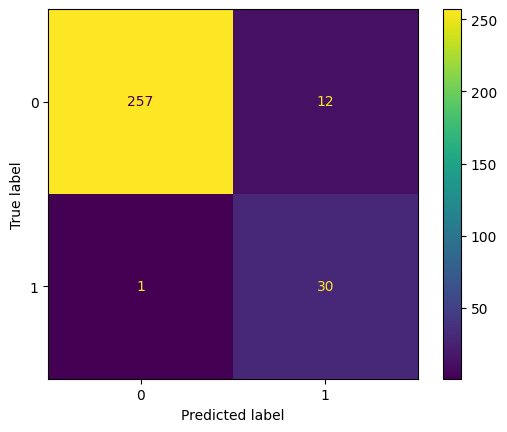

In [ ]:
print("\n🔬 Aplicando SMOTE...")
smote = SMOTE(sampling_strategy='minority',random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Dataset original: {Counter(y_train)}")
print(f"Dataset con SMOTE: {Counter(y_train_smote)}")

knn_smote = KNeighborsClassifier(n_neighbors=3, weights='distance')
knn_smote.fit(X_train_smote, y_train_smote)

y_pred = knn_smote.predict(X_test)

print("Modelo con tratamiento de desbalance:")
print(classification_report(y_test, y_pred, digits=3))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

# Análisis del desbalance
print(f"\n📊 Distribución de clases Entrenamiento Original:")
train_dist = Counter(y_train)
print(f"Clase 0 (mayoritaria): {train_dist[0]} ({train_dist[0]/len(y_train)*100:.2f}%)")
print(f"Clase 1 (minoritaria): {train_dist[1]} ({train_dist[1]/len(y_train)*100:.2f}%)")
print(f"Ratio de desbalance: 1:{train_dist[0]/train_dist[1]:.1f}")


# Análisis del desbalance
print(f"\n📊 Distribución de clases Entrenamiento Balanceada:")
train_dist = Counter(y_train_smote)
print(f"Clase 0 (mayoritaria): {train_dist[0]} ({train_dist[0]/len(y_train_smote)*100:.2f}%)")
print(f"Clase 1 (minoritaria): {train_dist[1]} ({train_dist[1]/len(y_train_smote)*100:.2f}%)")
print(f"Ratio de desbalance: 1:{train_dist[0]/train_dist[1]:.1f}")


# K-NN + SMOTE

Evaluación con SMOTE usando Stratified K-Fold Cross-Validation
Accuracy por fold: [0.945 0.93  0.95  0.915 0.92 ]
Precision macro por fold: [0.82755299 0.79829545 0.85142857 0.77122016 0.78184543]
Recall macro por fold: [0.925      0.85       0.90901836 0.8264166  0.85022612]
Recall clase 0 por fold: [0.95       0.95       0.96089385 0.93854749 0.93854749]
Recall clase 1 por fold: [0.9        0.75       0.85714286 0.71428571 0.76190476]
F1 macro por fold: [0.86739799 0.82124617 0.87718005 0.79506962 0.81060606]

Promedios:
Accuracy promedio: 0.932
Precision macro promedio: 0.8060685201764034
Recall macro promedio: 0.8721322160148975
Recall clase 0 promedio: 0.9475977653631285
Recall clase 1 promedio: 0.7966666666666666
F1 macro promedio: 0.8342999774249715


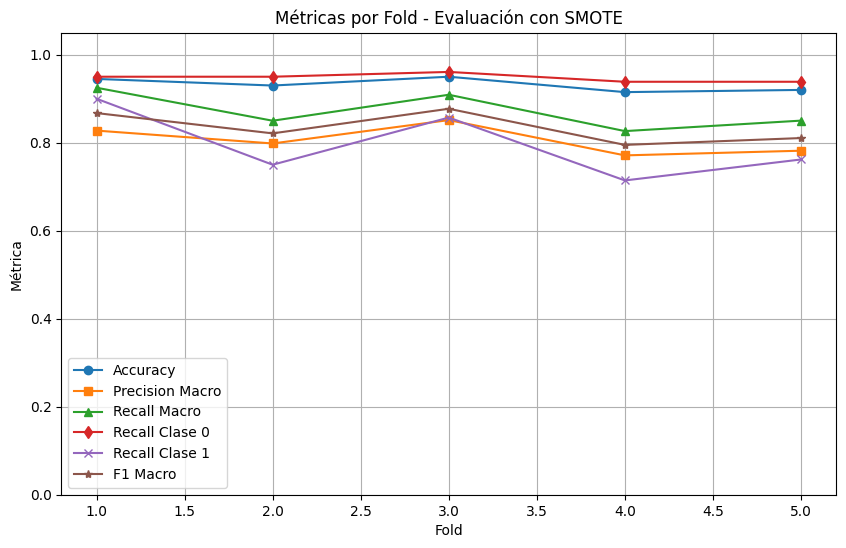

In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import make_scorer, recall_score
from sklearn.model_selection import cross_validate
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import numpy as np

# Scorers personalizados para recall por clase
scorers = {
    'accuracy': 'accuracy',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro',
    'f1_macro': 'f1_macro',
    'recall_0': make_scorer(recall_score, pos_label=0),
    'recall_1': make_scorer(recall_score, pos_label=1)
}

pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf', KNeighborsClassifier(n_neighbors=3))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_validate(pipeline, X, y, scoring=scorers, cv=cv)

print("Evaluación con SMOTE usando Stratified K-Fold Cross-Validation")
print("Accuracy por fold:", scores['test_accuracy'])
print("Precision macro por fold:", scores['test_precision_macro'])
print("Recall macro por fold:", scores['test_recall_macro'])
print("Recall clase 0 por fold:", scores['test_recall_0'])
print("Recall clase 1 por fold:", scores['test_recall_1'])
print("F1 macro por fold:", scores['test_f1_macro'])

print("\nPromedios:")
print("Accuracy promedio:", scores['test_accuracy'].mean())
print("Precision macro promedio:", scores['test_precision_macro'].mean())
print("Recall macro promedio:", scores['test_recall_macro'].mean())
print("Recall clase 0 promedio:", scores['test_recall_0'].mean())
print("Recall clase 1 promedio:", scores['test_recall_1'].mean())
print("F1 macro promedio:", scores['test_f1_macro'].mean())

# Gráfica comparativa de métricas por fold
plt.figure(figsize=(10, 6))
folds = np.arange(1, 6)
plt.plot(folds, scores['test_accuracy'], label='Accuracy', marker='o')
plt.plot(folds, scores['test_precision_macro'], label='Precision Macro', marker='s')
plt.plot(folds, scores['test_recall_macro'], label='Recall Macro', marker='^')
plt.plot(folds, scores['test_recall_0'], label='Recall Clase 0', marker='d')
plt.plot(folds, scores['test_recall_1'], label='Recall Clase 1', marker='x')
plt.plot(folds, scores['test_f1_macro'], label='F1 Macro', marker='*')
plt.xlabel('Fold')
plt.ylabel('Métrica')
plt.title('Métricas por Fold - Evaluación con SMOTE')
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)
plt.show()

## Con Random Oversampling

Evaluación con RandomOverSampler usando Stratified K-Fold Cross-Validation
Accuracy por fold: [0.95  0.955 0.95  0.94  0.935]
Precision macro por fold: [0.84564394 0.88092469 0.87816226 0.84038308 0.85054348]
Recall macro por fold: [0.90555556 0.86388889 0.84596967 0.84038308 0.7745411 ]
Recall clase 0 por fold: [0.96111111 0.97777778 0.97765363 0.96648045 0.97765363]
Recall clase 1 por fold: [0.85       0.75       0.71428571 0.71428571 0.57142857]
F1 macro por fold: [0.87231869 0.87215001 0.86111111 0.84038308 0.80641799]

Promedios:
Accuracy promedio: 0.946
Precision macro promedio: 0.8591314884280775
Recall macro promedio: 0.8460676598386095
Recall clase 0 promedio: 0.9721353196772192
Recall clase 1 promedio: 0.7200000000000001
F1 macro promedio: 0.8504761766302806


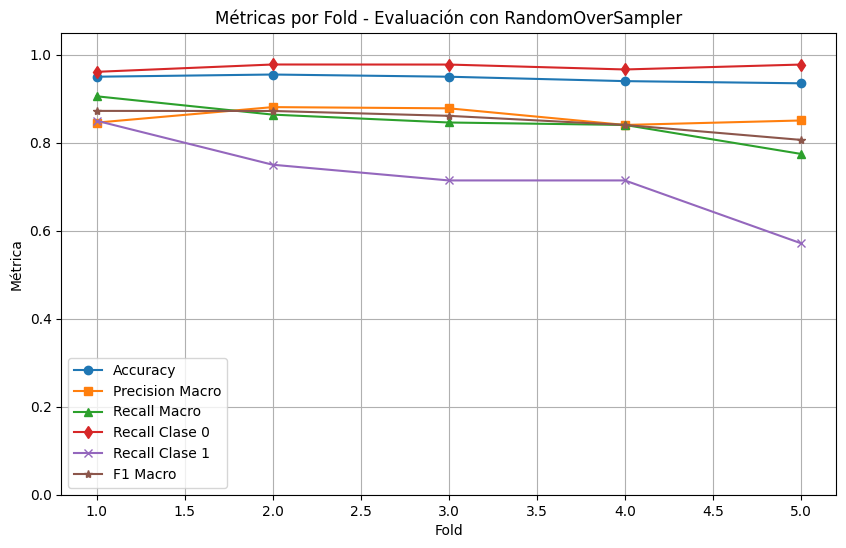

In [ ]:
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import make_scorer, recall_score
from sklearn.model_selection import cross_validate
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import numpy as np

# Scorers personalizados para recall por clase
scorers = {
    'accuracy': 'accuracy',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro',
    'f1_macro': 'f1_macro',
    'recall_0': make_scorer(recall_score, pos_label=0),
    'recall_1': make_scorer(recall_score, pos_label=1)
}

pipeline = ImbPipeline([
    ('smote', RandomOverSampler(random_state=42)),
    ('clf', KNeighborsClassifier(n_neighbors=3))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_validate(pipeline, X, y, scoring=scorers, cv=cv)

print("Evaluación con RandomOverSampler usando Stratified K-Fold Cross-Validation")
print("Accuracy por fold:", scores['test_accuracy'])
print("Precision macro por fold:", scores['test_precision_macro'])
print("Recall macro por fold:", scores['test_recall_macro'])
print("Recall clase 0 por fold:", scores['test_recall_0'])
print("Recall clase 1 por fold:", scores['test_recall_1'])
print("F1 macro por fold:", scores['test_f1_macro'])

print("\nPromedios:")
print("Accuracy promedio:", scores['test_accuracy'].mean())
print("Precision macro promedio:", scores['test_precision_macro'].mean())
print("Recall macro promedio:", scores['test_recall_macro'].mean())
print("Recall clase 0 promedio:", scores['test_recall_0'].mean())
print("Recall clase 1 promedio:", scores['test_recall_1'].mean())
print("F1 macro promedio:", scores['test_f1_macro'].mean())

# Gráfica comparativa de métricas por fold
plt.figure(figsize=(10, 6))
folds = np.arange(1, 6)
plt.plot(folds, scores['test_accuracy'], label='Accuracy', marker='o')
plt.plot(folds, scores['test_precision_macro'], label='Precision Macro', marker='s')
plt.plot(folds, scores['test_recall_macro'], label='Recall Macro', marker='^')
plt.plot(folds, scores['test_recall_0'], label='Recall Clase 0', marker='d')
plt.plot(folds, scores['test_recall_1'], label='Recall Clase 1', marker='x')
plt.plot(folds, scores['test_f1_macro'], label='F1 Macro', marker='*')
plt.xlabel('Fold')
plt.ylabel('Métrica')
plt.title('Métricas por Fold - Evaluación con RandomOverSampler')
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)
plt.show()

# Reporte con classification_report_imbalanced + Stratified Cross-Validation

In [ ]:
# Reporte con classification_report_imbalanced + Stratified Cross-Validation
from sklearn.model_selection import StratifiedKFold
from imblearn.metrics import classification_report_imbalanced
from sklearn.base import clone
from sklearn.tree import DecisionTreeClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
clf = DecisionTreeClassifier(random_state=42)
pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf', KNeighborsClassifier(n_neighbors=3))
])

sin_smote_avg = defaultdict(list)
con_smote_avg = defaultdict(list)
sin_smote_gmean = []
con_smote_gmean = []
sin_smote_bal = []
con_smote_bal = []

print("\nReportes por Fold usando classification_report_imbalanced:")

for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
    print(f"\nFold {fold_idx} - Sin SMOTE")
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model = clone(clf)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    report_sin = classification_report_imbalanced(y_test, y_pred, output_dict=True)
    print(classification_report_imbalanced(y_test, y_pred))
    for label in ['0', '1']:
        if label in report_sin:
            cls_metrics = report_sin.get(label, {})
            sin_smote_avg[f"recall_{label}"].append(float(cls_metrics.get('recall', 0)))
            sin_smote_avg[f"precision_{label}"].append(float(cls_metrics.get('precision', 0)))
            sin_smote_avg[f"f1_{label}"].append(float(cls_metrics.get('f1-score', 0)))
    sin_smote_gmean.append(float(report_sin.get('G-mean', 0)))
    sin_smote_bal.append(float(report_sin.get('IBA', 0)))

    print(f"\nFold {fold_idx} - Con SMOTE")
    model_smote = clone(pipeline)
    model_smote.fit(X_train, y_train)
    y_pred_smote = model_smote.predict(X_test)
    report_con = classification_report_imbalanced(y_test, y_pred_smote, output_dict=True)
    print(classification_report_imbalanced(y_test, y_pred_smote))
    for label in ['0', '1']:
        if label in report_con:
            cls_metrics = report_con.get(label, {})
            con_smote_avg[f"recall_{label}"].append(float(cls_metrics.get('recall', 0)))
            con_smote_avg[f"precision_{label}"].append(float(cls_metrics.get('precision', 0)))
            con_smote_avg[f"f1_{label}"].append(float(cls_metrics.get('f1-score', 0)))
    con_smote_gmean.append(float(report_con.get('G-mean', 0)))
    con_smote_bal.append(float(report_con.get('IBA', 0)))




Reportes por Fold usando classification_report_imbalanced:

Fold 1 - Sin SMOTE
                   pre       rec       spe        f1       geo       iba       sup

          0       0.98      0.94      0.80      0.96      0.87      0.77       180
          1       0.62      0.80      0.94      0.70      0.87      0.74        20

avg / total       0.94      0.93      0.81      0.93      0.87      0.76       200


Fold 1 - Con SMOTE
                   pre       rec       spe        f1       geo       iba       sup

          0       0.99      0.95      0.90      0.97      0.92      0.86       180
          1       0.67      0.90      0.95      0.77      0.92      0.85        20

avg / total       0.96      0.94      0.91      0.95      0.92      0.86       200


Fold 2 - Sin SMOTE
                   pre       rec       spe        f1       geo       iba       sup

          0       0.96      0.99      0.60      0.97      0.77      0.62       180
          1       0.86      0.60      0.99 

# Ejemplo con Undersampling

Estrategias enfocadas a reducir la clase mayoritaria: Random Undersampling y One-sided selection



🔬 Aplicando RUS...
Dataset original: Counter({np.int64(0): 626, np.int64(1): 74})
Dataset con RUS: Counter({np.int64(0): 74, np.int64(1): 74})
Modelo con tratamiento de desbalance:
              precision    recall  f1-score   support

           0      0.996     0.993     0.994       269
           1      0.938     0.968     0.952        31

    accuracy                          0.990       300
   macro avg      0.967     0.980     0.973       300
weighted avg      0.990     0.990     0.990       300


📊 Distribución de clases Entrenamiento Original:
Clase 0 (mayoritaria): 626 (89.43%)
Clase 1 (minoritaria): 74 (10.57%)
Ratio de desbalance: 1:8.5

📊 Distribución de clases Entrenamiento Balanceada:
Clase 0 (mayoritaria): 74 (50.00%)
Clase 1 (minoritaria): 74 (50.00%)
Ratio de desbalance: 1:1.0


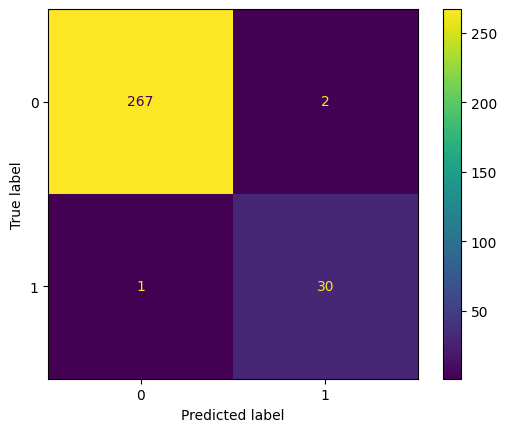

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
print("\n🔬 Aplicando RUS...")
rus = RandomUnderSampler(sampling_strategy='majority',random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

print(f"Dataset original: {Counter(y_train)}")
print(f"Dataset con RUS: {Counter(y_train_rus)}")

knn_rus = KNeighborsClassifier(n_neighbors=3, weights='distance')
knn_rus.fit(X_train_rus, y_train_rus)

y_pred = knn_rus.predict(X_test)

print("Modelo con tratamiento de desbalance:")
print(classification_report(y_test, y_pred, digits=3))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

# Análisis del desbalance
print(f"\n📊 Distribución de clases Entrenamiento Original:")
train_dist = Counter(y_train)
print(f"Clase 0 (mayoritaria): {train_dist[0]} ({train_dist[0]/len(y_train)*100:.2f}%)")
print(f"Clase 1 (minoritaria): {train_dist[1]} ({train_dist[1]/len(y_train)*100:.2f}%)")
print(f"Ratio de desbalance: 1:{train_dist[0]/train_dist[1]:.1f}")


# Análisis del desbalance
print(f"\n📊 Distribución de clases Entrenamiento Balanceada:")
train_dist = Counter(y_train_rus)
print(f"Clase 0 (mayoritaria): {train_dist[0]} ({train_dist[0]/len(y_train_rus)*100:.2f}%)")
print(f"Clase 1 (minoritaria): {train_dist[1]} ({train_dist[1]/len(y_train_rus)*100:.2f}%)")
print(f"Ratio de desbalance: 1:{train_dist[0]/train_dist[1]:.1f}")

Evaluación con Random Undersampling usando Stratified K-Fold Cross-Validation
Accuracy por fold: [0.935 0.865 0.915 0.885 0.9  ]
Precision macro por fold: [0.80349303 0.68736528 0.77338767 0.72391599 0.74327162]
Recall macro por fold: [0.94166667 0.81388889 0.91048151 0.85168928 0.83905294]
Recall clase 0 por fold: [0.93333333 0.87777778 0.91620112 0.89385475 0.91620112]
Recall clase 1 por fold: [0.95       0.75       0.9047619  0.80952381 0.76190476]
F1 macro por fold: [0.85392438 0.72379929 0.82081686 0.76471792 0.77895668]

Promedios:
Accuracy promedio: 0.9
Precision macro promedio: 0.7462867173224736
Recall macro promedio: 0.8713558570541811
Recall clase 0 promedio: 0.9074736188702669
Recall clase 1 promedio: 0.8352380952380953
F1 macro promedio: 0.7884430257946787


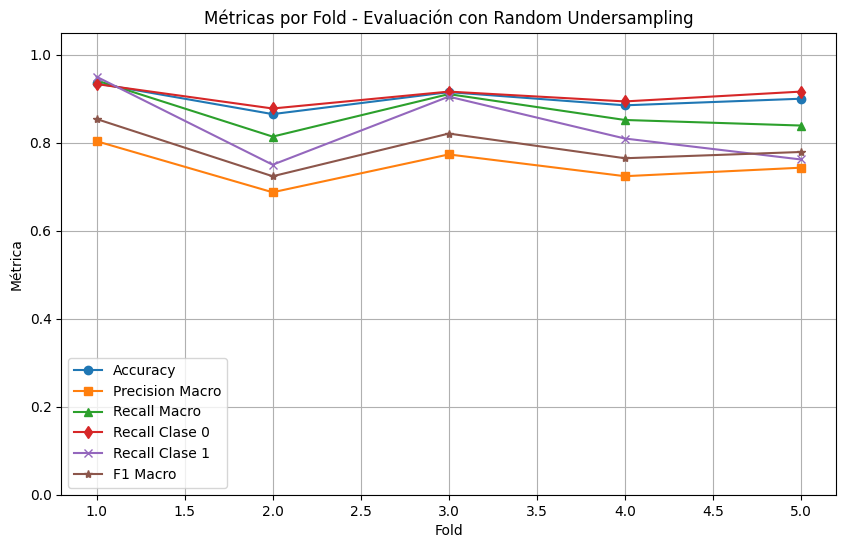

In [ ]:
from imblearn.under_sampling import RandomUnderSampler, TomekLinks, NearMiss
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import make_scorer, recall_score
from sklearn.model_selection import cross_validate
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import numpy as np

X, y = make_classification(n_samples=1000, n_features=10, n_informative=5,
                           n_redundant=0, weights=[0.9, 0.1], random_state=42)

# Scorers personalizados para recall por clase
scorers = {
    'accuracy': 'accuracy',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro',
    'f1_macro': 'f1_macro',
    'recall_0': make_scorer(recall_score, pos_label=0),
    'recall_1': make_scorer(recall_score, pos_label=1)
}

pipeline = ImbPipeline([
    ('rus', RandomUnderSampler(random_state=42)),
    ('clf', KNeighborsClassifier(n_neighbors=3))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_validate(pipeline, X, y, scoring=scorers, cv=cv)

print("Evaluación con Random Undersampling usando Stratified K-Fold Cross-Validation")
print("Accuracy por fold:", scores['test_accuracy'])
print("Precision macro por fold:", scores['test_precision_macro'])
print("Recall macro por fold:", scores['test_recall_macro'])
print("Recall clase 0 por fold:", scores['test_recall_0'])
print("Recall clase 1 por fold:", scores['test_recall_1'])
print("F1 macro por fold:", scores['test_f1_macro'])

print("\nPromedios:")
print("Accuracy promedio:", scores['test_accuracy'].mean())
print("Precision macro promedio:", scores['test_precision_macro'].mean())
print("Recall macro promedio:", scores['test_recall_macro'].mean())
print("Recall clase 0 promedio:", scores['test_recall_0'].mean())
print("Recall clase 1 promedio:", scores['test_recall_1'].mean())
print("F1 macro promedio:", scores['test_f1_macro'].mean())

# Gráfica comparativa de métricas por fold
plt.figure(figsize=(10, 6))
folds = np.arange(1, 6)
plt.plot(folds, scores['test_accuracy'], label='Accuracy', marker='o')
plt.plot(folds, scores['test_precision_macro'], label='Precision Macro', marker='s')
plt.plot(folds, scores['test_recall_macro'], label='Recall Macro', marker='^')
plt.plot(folds, scores['test_recall_0'], label='Recall Clase 0', marker='d')
plt.plot(folds, scores['test_recall_1'], label='Recall Clase 1', marker='x')
plt.plot(folds, scores['test_f1_macro'], label='F1 Macro', marker='*')
plt.xlabel('Fold')
plt.ylabel('Métrica')
plt.title('Métricas por Fold - Evaluación con Random Undersampling')
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)
plt.show()

# Desbalance en Problemas Multiclase

Distribución original de clases: Counter({np.int64(0): 1039, np.int64(1): 300, np.int64(2): 161})


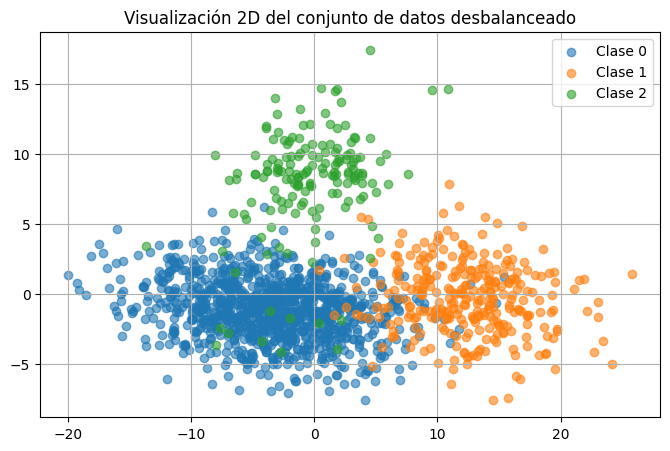

F1 Macro sin técnicas de remuestreo: [0.9226947  0.9137714  0.92344115 0.8802935  0.90984483]
F1 Macro con SMOTE: [0.89278528 0.93080048 0.89193514 0.8890387  0.90908891]
F1 Macro con One-Sided Selection: [0.81748398 0.91883539 0.92687154 0.63574861 0.83036616]


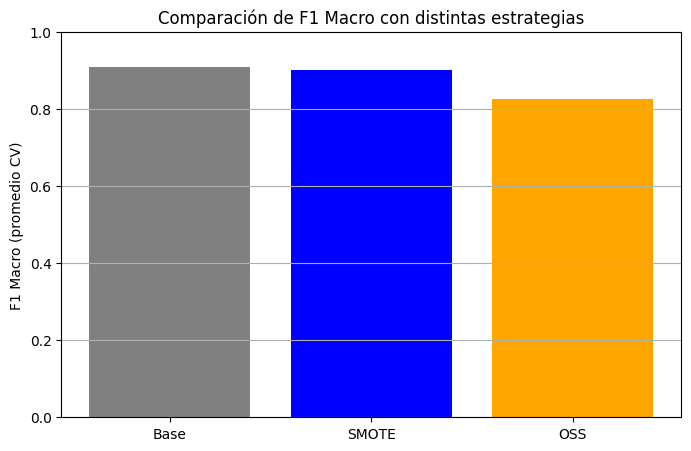

In [ ]:
# Ejercicio: Desbalance multiclase con árbol de decisión y estrategias de remuestreo

# Paso 1: Importar librerías necesarias
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTEENN
from imblearn.under_sampling import OneSidedSelection
from imblearn.over_sampling import SMOTE
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Paso 2: Crear un conjunto de datos multiclase desbalanceado
X, y = make_classification(n_classes=3, class_sep=2,
                           weights=[0.7, 0.2, 0.1],
                           n_informative=10, n_redundant=2,
                           n_features=20, n_clusters_per_class=1,
                           n_samples=1500, random_state=42)

print("Distribución original de clases:", Counter(y))

# Paso 3: Visualización simple (reducida a 2D si se desea)
from sklearn.decomposition import PCA
X_vis = PCA(n_components=2).fit_transform(X)
plt.figure(figsize=(8, 5))
for class_value in np.unique(y):
    plt.scatter(X_vis[y == class_value, 0], X_vis[y == class_value, 1], label=f"Clase {class_value}", alpha=0.6)
plt.title("Visualización 2D del conjunto de datos desbalanceado")
plt.legend()
plt.grid(True)
plt.show()

# Paso 4: Definir modelos y estrategias
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = 'f1_macro'

# 1. Árbol sin tratamiento de desbalance
model_base = DecisionTreeClassifier(random_state=42)
score_base = cross_val_score(model_base, X, y, scoring=scoring, cv=cv)
print("F1 Macro sin técnicas de remuestreo:", score_base)

# 2. Árbol con SMOTE
pipeline_smote = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf', DecisionTreeClassifier(random_state=42))
])
score_smote = cross_val_score(pipeline_smote, X, y, scoring=scoring, cv=cv)
print("F1 Macro con SMOTE:", score_smote)

# 3. Árbol con One-Sided Selection
pipeline_oss = ImbPipeline([
    ('oss', OneSidedSelection(random_state=42)),
    ('clf', DecisionTreeClassifier(random_state=42))
])
score_oss = cross_val_score(pipeline_oss, X, y, scoring=scoring, cv=cv)
print("F1 Macro con One-Sided Selection:", score_oss)

# Paso 5: Visualización comparativa
labels = ['Base', 'SMOTE', 'OSS']
scores = [np.mean(score_base), np.mean(score_smote), np.mean(score_oss)]

plt.figure(figsize=(8, 5))
plt.bar(labels, scores, color=['gray', 'blue', 'orange'])
plt.title("Comparación de F1 Macro con distintas estrategias")
plt.ylabel("F1 Macro (promedio CV)")
plt.ylim(0, 1)
plt.grid(axis='y')
plt.show()